In [1]:
from IPython.display import HTML
from al_graph_research.data.datasets import GaussianDataset
import al_graph_research.experiments.only_edges.visualizations as viz_only_edges
import al_graph_research.visualization.visualizations as viz
import al_graph_research.experiments.only_edges.configurations as configs


In [2]:
mean1 = [.5, .4]
mean2 = [.8, -1.6]
mean3 = [-.4, .5]
mean_arr = [mean1, mean2, mean3]
cov = [[.1, 0], [0, .1]]
dataset = GaussianDataset(
    n_per_cluster=500,
    cov=cov,
    mean_arr=mean_arr,
    n_blobs=3,
    seed=42,
)

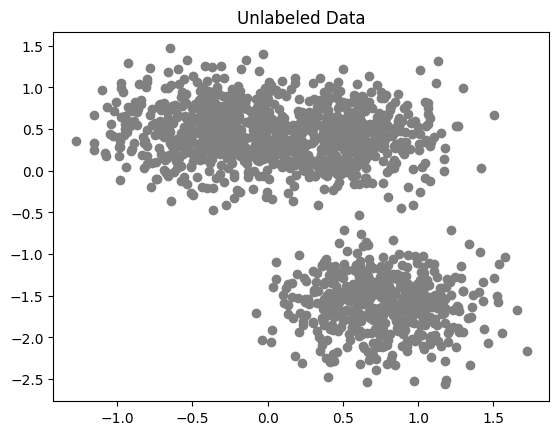

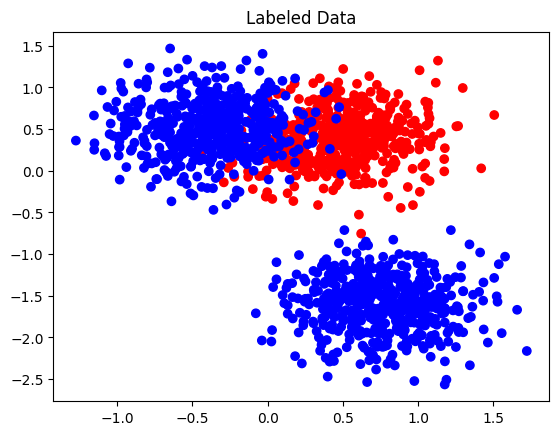

In [3]:
viz.dataset_visualization(dataset.data, dataset.labels)


In [4]:
config_zero = configs.ExperimentConfigurations.THREE_BLOBS_ZERO
exp_zero = configs.ExperimentConfigBuilder.build_experiment(config_zero, seed=42)
results_zero = exp_zero.run(dataset)

config_negate = configs.ExperimentConfigurations.THREE_BLOBS_NEGATE
exp_negate = configs.ExperimentConfigBuilder.build_experiment(config_negate, seed=42)
results_negate = exp_negate.run(dataset)





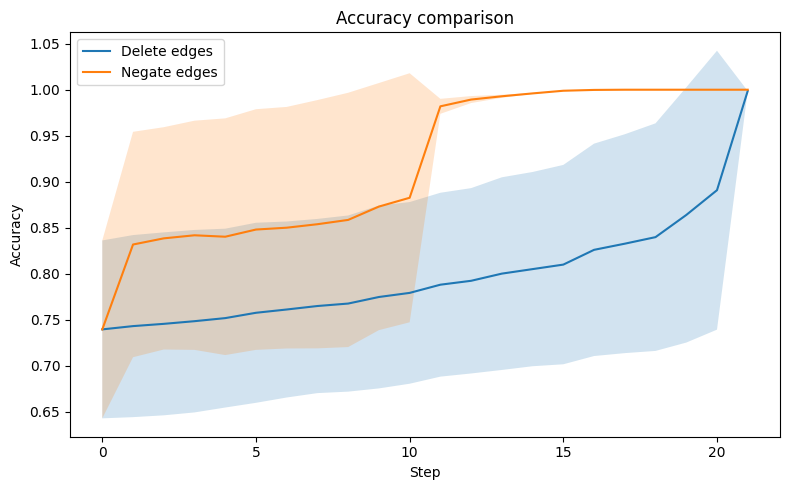

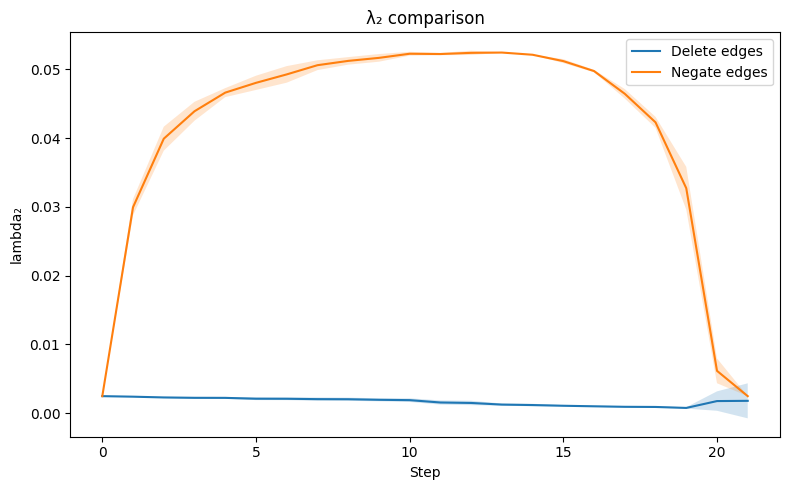

In [5]:
viz_only_edges.plot_metric_comparison(
    [results_zero, results_negate],
    "accuracy_history",
    ["Delete edges", "Negate edges"],
    title="Accuracy comparison"
)

viz_only_edges.plot_metric_comparison(
    [results_zero, results_negate],
    "lam2_history",
    ["Delete edges", "Negate edges"],
    title="λ₂ comparison"
)




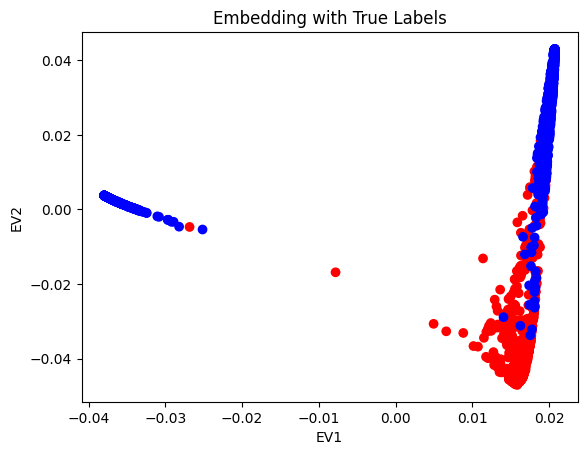

22
(1500, 2)


In [6]:
run = results_negate.runs[0]
run.embedding_history[0]
viz.plot_embedding_with_labels(run.embedding_history[0], dataset.labels)

print(len(run.embedding_history))
print(run.embedding_history[0].shape)

In [7]:
anim = viz_only_edges.animate_embedding_history(run, dataset.labels)
HTML(anim.to_jshtml())

In [8]:
viz_only_edges.animate_embedding_true_vs_pred
anim = viz_only_edges.animate_embedding_true_vs_pred(run, dataset.labels)
HTML(anim.to_jshtml())